In [165]:
# Python Imaging Library (PIL)의 Image 모듈을 불러옴. 이미지 파일을 열고 조작하는 데 사용함.
from PIL import Image


# Matplotlib의 pyplot 모듈을 plt 별칭으로 불러옴. 시각화에 사용함.
import matplotlib.pyplot as plt


# PyTorch 핵심 라이브러리를 불러옴.
import torch


# 신경망 레이어(nn) 모듈을 불러옴.
import torch.nn as nn


# 옵티마이저(optim) 모듈을 불러옴.
import torch.optim as optim


# TorchVision 라이브러리를 불러옴. (이미지 변환 및 데이터셋 등에 사용)
import torchvision

import torchvision.transforms as transforms
import numpy as np
# 학습에 사용할 장치(Device)를 설정함. CUDA(GPU)가 사용 가능하면 'cuda'를, 아니면 'cpu'를 선택함.
dvc = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 나눔바른고딕(NanumBarunGothic) 또는 나눔고딕(NanumGothic) 설정
plt.rc('font', family='NanumBarunGothic') 

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


In [166]:
# 이미지 파일 열고 전처리 pytorch 텐서 변환 함수
def image_to_tensor(image_filepath, image_dimension=128):
    img = Image.open(image_filepath).convert('RGB')

    plt.figure()
    plt.title(image_filepath)
    plt.imshow(img)

    # 이미지의 최대해상도가 지정된 크기 (image_dimension) 보다 작거나 같으면 >> 원본 사용
    if max(img.size) <= image_dimension:
        img_size = max(img.size)
    # 이미지의 최대 해상도가 지정된 크기보다 크면 >> 지정된 크기 사용
    else:
        img_size = image_dimension

    # 이미지를 텐서로 변환하기 위해 변환 파이프라인 정의 (Compose)
    torch_transformation = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor()
    ])

    img = torch_transformation(img).unsqueeze(0) # 배치차원 증가

    return img.to(dvc, torch.float)

In [167]:
a = torch.tensor([
    [1,1,1],
    [2,2,2],
    [3,3,3]
])

In [168]:
a.unsqueeze(1)

tensor([[[1, 1, 1]],

        [[2, 2, 2]],

        [[3, 3, 3]]])

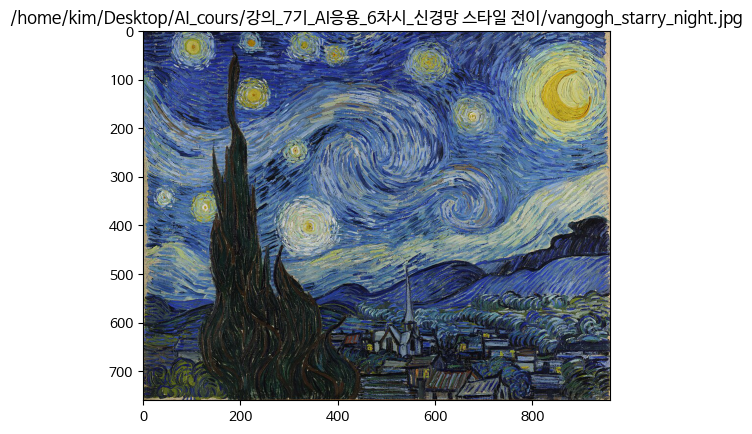

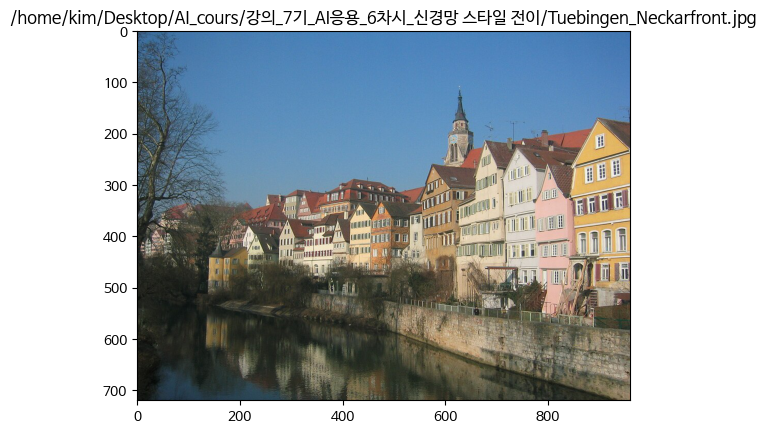

In [169]:
style_image = image_to_tensor('/home/kim/Desktop/AI_cours/강의_7기_AI응용_6차시_신경망 스타일 전이/vangogh_starry_night.jpg')
content_image = image_to_tensor('/home/kim/Desktop/AI_cours/강의_7기_AI응용_6차시_신경망 스타일 전이/Tuebingen_Neckarfront.jpg')

In [170]:
# Gram Matrix
def gram_matrix(ip):
    b, c, h, w = ip.size()
    # 입력 텐서의 4가지 차원 (배치, 채널, 높이, 너비)

    # 텐서의 공간 차원(높이*너비) >> 하나의 벡터(평탄화 flatten)
    # 텐서 크기(b, c, w*h)
    features = ip.view(b, c, h*w)

    # 배치 행렬 곱 (b,c,h*w) @ (b,h*w,c) >> (b,c,c)
    gram = torch.bmm(features, features.transpose(1,2))

    # 정규화 (c * h * w)
    # 요소의 총 개수로 나누어 스케일 조정
    return gram.div(c*h*w)

In [171]:
vgg19 = torchvision.models.vgg19(pretrained=True).to(dvc)

/home/kim/miniconda3/envs/yolo_env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kim/miniconda3/envs/yolo_env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [172]:
vgg19 = vgg19.features
# vgg19모델의 특징 추출기만 사용

In [173]:
vgg19[0]

Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

In [174]:
# 신경망 활용한 스타일 트랜스퍼 특징 추출 작업에서 필수적 단계
# 가져온 사전 학습 모델의 모든 파라미터 고정(freezing)
for param in vgg19.parameters():
    param.requires_grad_(False)

In [175]:
# pooling 작업 (maxpool >> avgpool 교체)
# >> maxpool 대신 avgpool 사용시 스타일 전송 품질 높아짐

# 합성곱 레이어의 인덱스 저장할 빈 리스트 생성
conv_indices = []

# vgg19 특징 추출 레이더들 (sequential module) 순회
for i in range(len(vgg19)):
    if vgg19[i]._get_name() == 'MaxPool2d':
        vgg19[i] = nn.AvgPool2d(kernel_size=vgg19[i].kernel_size,
                                stride=vgg19[i].stride,
                                padding=vgg19[i].padding)
    if vgg19[i]._get_name() == 'Conv2d':
        conv_indices.append(i) # 해당 레이어의 인덱스(i) >> 리스트에 추가
    

conv_indices = dict(enumerate(conv_indices, 1)) # 뒤에 1은 0이 아닌 1부터 시작하겠다.
# 수집된 conv_indices 리스트에서 1부터 순서를 매긴 dict() 생성
# 예: {1:..., 2:..., 3:...}
# 합성곱 레이어가 있는 인덱스를 순서대로 저장한다.
print(conv_indices)

{1: 0, 2: 2, 3: 5, 4: 7, 5: 10, 6: 12, 7: 14, 8: 16, 9: 19, 10: 21, 11: 23, 12: 25, 13: 28, 14: 30, 15: 32, 16: 34}


clip until the last relevant layer

In [176]:
layers = {1:'s', 2:'s', 3:'sc', 4:'c', 5:'s'}

In [177]:
# vgg19 모델의 특징 추출기(features) 부분을 nn.ModuleList 변환
# 전체 모델이 완전연결층(fully connected layer)으로 구정된 것 중 불필요한 뒷부분 잘라내고(clip)
# 핵심적인 특징추출기만 남기는 모델 경량화 작업

vgg_layers = nn.ModuleList(vgg19) # 레이어를 순서대로 리스트와 비슷한 구조로 만듬

last_layer_idx = conv_indices[max(conv_indices.keys())] # 가장 마지막에 사용하는 conv 레이어 인덱스 포함

# vgg 레이어 리스트를 시작부터 마지막 합성곱 레이어까지 자름
vgg19_layers_trimmed = vgg_layers[:last_layer_idx+1]

# 잘라낸 레이어들을 nn.Se
neural_style_transfer_model = nn.Sequential(*vgg19_layers_trimmed)

# print(neural_style_transfer_model)

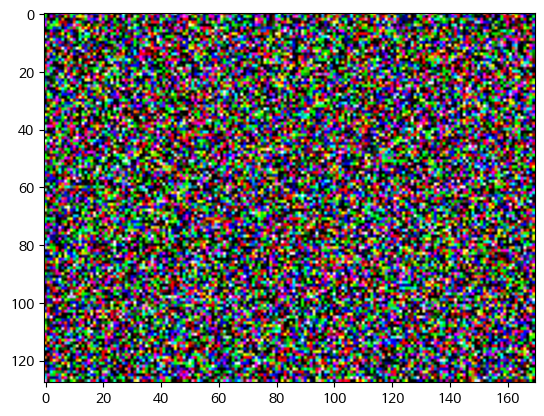

In [178]:
ip_image = torch.randn(content_image.data.size(), device=dvc)
plt.figure()
plt.imshow(ip_image.squeeze(0).cpu().detach().numpy().transpose(1,2,0).clip(0,1))
# 텐서에서 배치차원(0번)제거, 넘파이 변환 위해 cpu, detach, numpy
# 그런 뒤에 채널 순서 맞춰주고  chw >> hwc [0,1]
plt.show()

In [179]:
# num_epochs = 300
# # 스타일 손실에 부여할 가중치 설정함. 콘텐츠 손실보다 훨씬 크게 설정함
# wt_style = 1e6
# # 콘텐츠 손실에 부여할 가중치 설정
# wt_content = 1

# # 각 에폭별(학습할 때마다) 스타일 손실,콘텐츠 손실 저장할 리스트 초기화
# style_losses = []
# content_losses = []

# # 옵티마이저 정의함. 최적화 대상은 ip_image 뿐이며, Adam을 사용, 학습률(lr) 0.1 설정
# opt = optim.Adam([ip_image.requires_grad_()], lr=0.1)

# for curr_epoch in range(1, num_epochs+1):
#     ip_image.data.clamp_(0,1)

#     opt.zero_grad()

#     epoch_style_loss = 0
#     epoch_content_loss = 0
#     # 현재 애폭(학습) 스타일 손실과 콘텐츠 손실 누적 변수를 0으로 초기화

#     for k in layers.keys(): # 현재 range(1,6) 와 같음
#         # layer k가 콘텐츠 손실('c') 계산할 때 포함된 경우
#         if 'c' in layers[k]:
#             # 콘텐츠 이미지 특징 추출 >> 변화도 계산에서 제외(detach)
#             target = neural_style_transfer_model[:conv_indices[k]+1](content_image).detach()
#             ip = neural_style_transfer_model[:conv_indices[k]+1](ip_image)
            
#             epoch_content_loss += torch.nn.functional.mse_loss(ip, target)

#         # layer k가 콘텐츠 손실('s') 계산할 때 포함된 경우
#         if 's' in layers[k]:
#             target = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](style_image).detach())
#             ip = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](ip_image))
            
#             epoch_style_loss += torch.nn.functional.mse_loss(ip, target)

#     epoch_content_loss *= wt_content
#     epoch_style_loss *= wt_style

#     total_loss = epoch_content_loss + epoch_style_loss

#     total_loss.backward()

#     if curr_epoch % 50 == 0:
#         print(f'epoch number {curr_epoch}')
#         print(f'content loss = {epoch_content_loss}, style loss = {epoch_style_loss}')
#         plt.figure()
#         plt.title(f'epoch number {curr_epoch}')

#         plt.imshow(ip_image.data.clamp_(0,1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))
#         plt.show()

#         content_losses.append(epoch_content_loss.item())
#         style_losses.append(epoch_style_loss.item())
    
#     opt.step()
#     # 옵티마이저 이용 변화도(gradient) 방향으로 

In [180]:
def total_variation_loss(img):
    # Total variation loss란 인접한 픽셀간 차이값이 너무 크지 않도록 규제 
    # 한 픽셀씩 어긋난 픽셀 리스트끼리 빼면 >> 
    loss = torch.sum(torch.abs(img[:,:,:,:-1] - img[:,:,:,1:])) +\
    torch.sum(torch.abs(img[:,:,:-1,:] - img[:,:,1:,:]))
    return loss

epoch number 50
content loss = 1.417589545249939, style loss = 0.4776960611343384


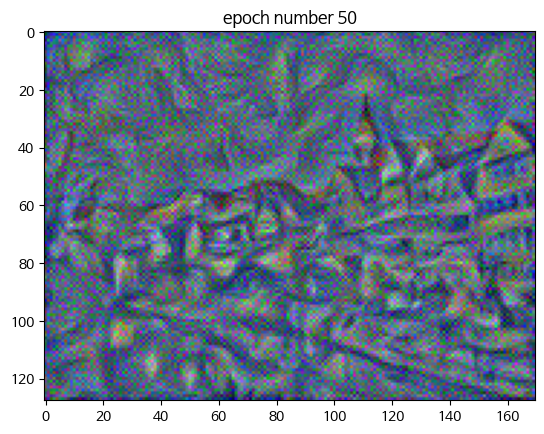

epoch number 100
content loss = 0.47370579838752747, style loss = 0.24260470271110535


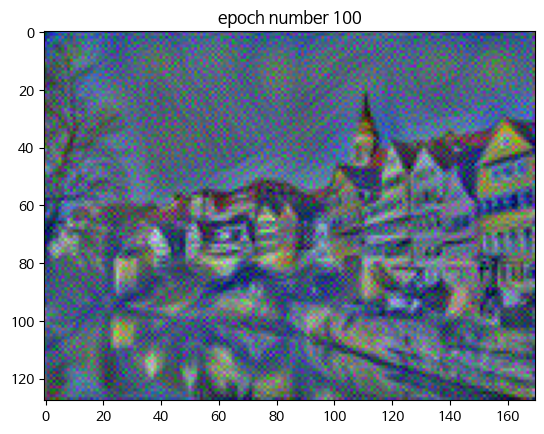

epoch number 150
content loss = 0.3754887878894806, style loss = 0.19980007410049438


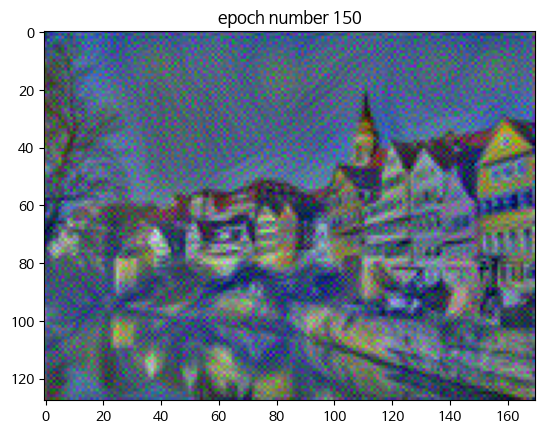

epoch number 200
content loss = 0.33742138743400574, style loss = 0.18229390680789948


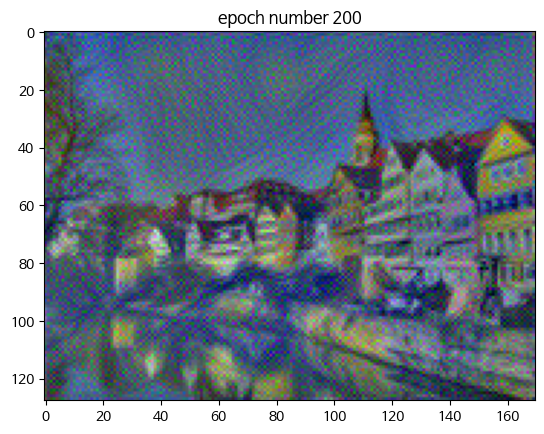

epoch number 250
content loss = 0.3183342218399048, style loss = 0.1741933375597


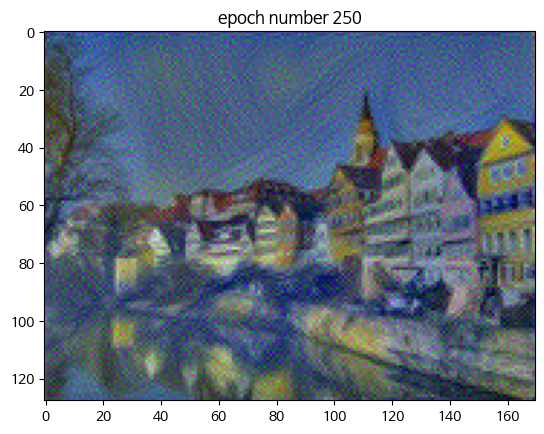

epoch number 300
content loss = 0.30810651183128357, style loss = 0.17023330926895142


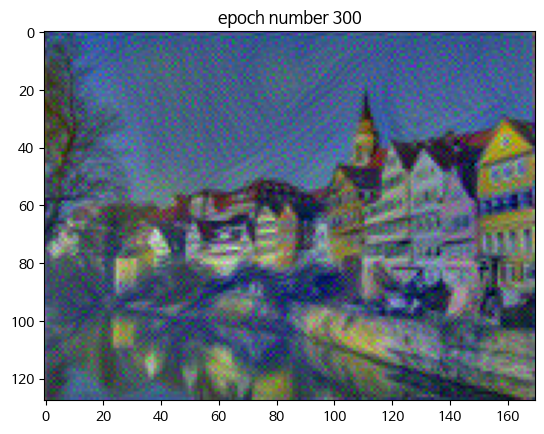

epoch number 350
content loss = 0.30195900797843933, style loss = 0.16827093064785004


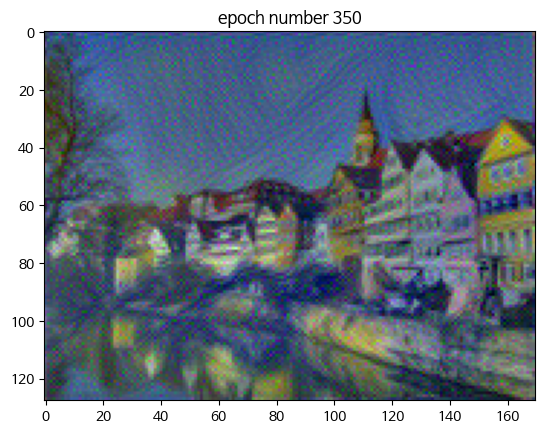

epoch number 400
content loss = 0.29771438241004944, style loss = 0.16735120117664337


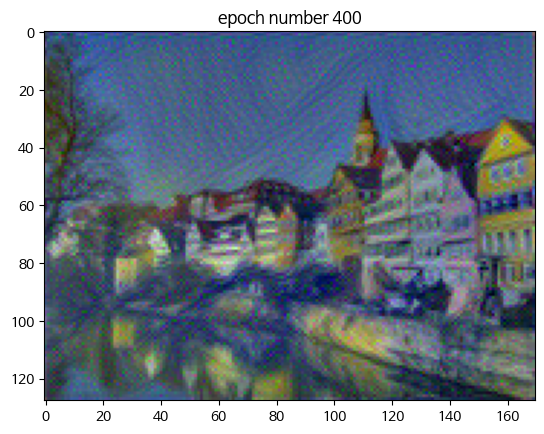

epoch number 450
content loss = 0.29476606845855713, style loss = 0.16682080924510956


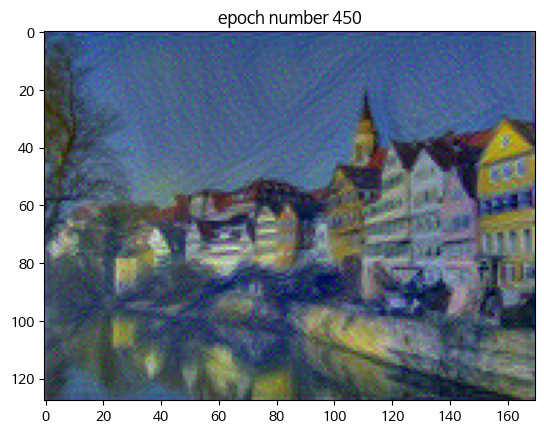

epoch number 500
content loss = 0.29249897599220276, style loss = 0.16652236878871918


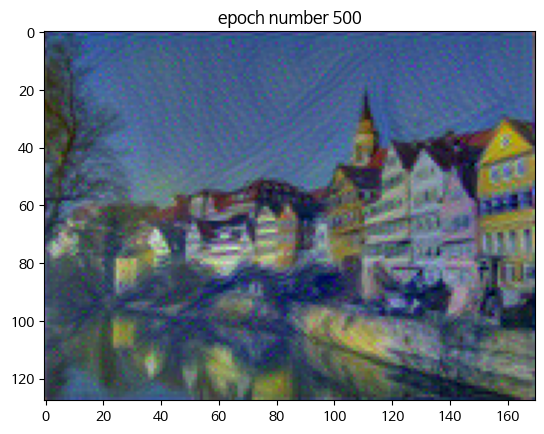

In [181]:
# tv loss 가중치 설정
wt_tv = 1e-5

num_epochs = 500
# 스타일 손실에 부여할 가중치 설정함. 콘텐츠 손실보다 훨씬 크게 설정함
wt_style = 1e6
# 콘텐츠 손실에 부여할 가중치 설정
wt_content = 1

# 각 에폭별(학습할 때마다) 스타일 손실,콘텐츠 손실 저장할 리스트 초기화
style_losses = []
content_losses = []

# 옵티마이저 정의함. 최적화 대상은 ip_image 뿐이며, Adam을 사용, 학습률(lr) 0.1 설정
opt = optim.Adam([ip_image.requires_grad_()], lr=0.1)

for curr_epoch in range(1, num_epochs+1):
    ip_image.data.clamp_(0,1)

    opt.zero_grad()

    epoch_style_loss = 0
    epoch_content_loss = 0
    # 현재 애폭(학습) 스타일 손실과 콘텐츠 손실 누적 변수를 0으로 초기화

    for k in layers.keys(): # 현재 range(1,6) 와 같음
        # layer k가 콘텐츠 손실('c') 계산할 때 포함된 경우
        if 'c' in layers[k]:
            # 콘텐츠 이미지 특징 추출 >> 변화도 계산에서 제외(detach)
            target = neural_style_transfer_model[:conv_indices[k]+1](content_image).detach()
            ip = neural_style_transfer_model[:conv_indices[k]+1](ip_image)
            
            epoch_content_loss += torch.nn.functional.mse_loss(ip, target)

        # layer k가 콘텐츠 손실('s') 계산할 때 포함된 경우
        if 's' in layers[k]:
            target = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](style_image).detach())
            ip = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](ip_image))
            
            epoch_style_loss += torch.nn.functional.mse_loss(ip, target)

    epoch_content_loss *= wt_content
    epoch_style_loss *= wt_style

    # tv loss 계산
    tv_loss = total_variation_loss(ip_image)

    total_loss = epoch_content_loss + epoch_style_loss + (tv_loss * wt_tv)

    total_loss.backward()

    if curr_epoch % 50 == 0:
        print(f'epoch number {curr_epoch}')
        print(f'content loss = {epoch_content_loss}, style loss = {epoch_style_loss}')
        plt.figure()
        plt.title(f'epoch number {curr_epoch}')

        plt.imshow(ip_image.data.clamp_(0,1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))
        plt.show()

        content_losses.append(epoch_content_loss.item())
        style_losses.append(epoch_style_loss.item())
    
    opt.step()
    # 옵티마이저 이용 변화도(gradient) 방향으로 

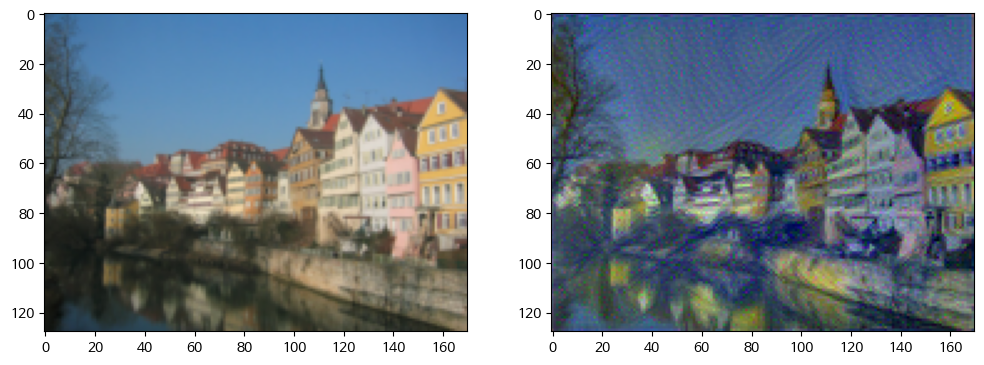

In [182]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(content_image.data.clamp_(0,1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))
plt.subplot(1,2,2)
plt.imshow(ip_image.data.clamp_(0,1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))
plt.show()

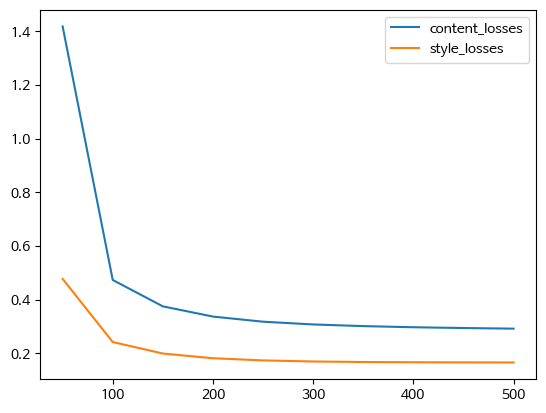

In [184]:
plt.plot(range(50,500+1,50), content_losses, label='content_losses')
plt.plot(range(50,500+1,50), style_losses, label='style_losses')
plt.legend()
plt.show()